In [7]:
# Retrieve the stored dataset variable
%store -r forest_cover_df

In [8]:
# Separate the input features from the target variable
features = forest_cover_df.drop('Cover_Type', axis=1)

target = forest_cover_df['Cover_Type']

In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and temporary sets
# 70% for training and 30% for validation and testing
train_features, temp_features, train_labels, temp_labels = train_test_split(
    features,
    target,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=target
)

# Split the temporary set into validation and test sets
# 15% validation and 15% test
valid_features, test_features, valid_labels, test_labels = train_test_split(
    temp_features,
    temp_labels,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=temp_labels
)

In [10]:
# Display the shapes of the training, validation, and test datasets
print("Train Features:", train_features.shape)

print("Validation Features:", valid_features.shape)

print("Test Features:", test_features.shape)

print("Train Labels:", train_labels.shape)

print("Validation Labels:", valid_labels.shape)

print("Test Labels:", test_labels.shape)

Train Features: (102123, 54)
Validation Features: (21883, 54)
Test Features: (21884, 54)
Train Labels: (102123,)
Validation Labels: (21883,)
Test Labels: (21884,)


In [11]:
# Display the class distribution across the training, validation, and test sets
print("\nTrain Class Distribution:")
print(train_labels.value_counts(normalize=True).sort_index())

print("\nValidation Class Distribution:")
print(valid_labels.value_counts(normalize=True).sort_index())

print("\nTest Class Distribution:")
print(test_labels.value_counts(normalize=True).sort_index())


Train Class Distribution:
Cover_Type
Aspen                0.021033
Cottonwood/Willow    0.014806
Douglas-fir          0.014806
Krummholz            0.014806
Lodgepole Pine       0.706501
Ponderosa Pine       0.014806
Spruce/Fir           0.213243
Name: proportion, dtype: float64

Validation Class Distribution:
Cover_Type
Aspen                0.021067
Cottonwood/Willow    0.014806
Douglas-fir          0.014806
Krummholz            0.014806
Lodgepole Pine       0.706484
Ponderosa Pine       0.014806
Spruce/Fir           0.213225
Name: proportion, dtype: float64

Test Class Distribution:
Cover_Type
Aspen                0.021020
Cottonwood/Willow    0.014805
Douglas-fir          0.014805
Krummholz            0.014805
Lodgepole Pine       0.706498
Ponderosa Pine       0.014805
Spruce/Fir           0.213261
Name: proportion, dtype: float64


In [12]:
import pandas as pd

# Define a function to identify and count outliers using the IQR method
def count_outliers_iqr(df, numerical_columns):
    outliers_count = {}

    for column in numerical_columns:
        # Calculate Q1, Q3, and IQR for the column
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify values outside the IQR bounds
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Store the outlier count for the column
        outliers_count[column] = outliers.shape[0]

    return outliers_count

In [13]:
# Define the numerical columns for outlier analysis
numerical_cols = [
    'Elevation',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

In [14]:
# Calculate the number of outliers in the training set
outlier_counts = count_outliers_iqr(train_features, numerical_cols)

# Display the outlier count for each numerical feature
print("Outlier counts for each numerical feature:\n", outlier_counts)

Outlier counts for each numerical feature:
 {'Elevation': 3146, 'Slope': 2377, 'Horizontal_Distance_To_Hydrology': 1813, 'Vertical_Distance_To_Hydrology': 4911, 'Horizontal_Distance_To_Roadways': 0, 'Hillshade_9am': 3680, 'Hillshade_Noon': 2264, 'Hillshade_3pm': 2159, 'Horizontal_Distance_To_Fire_Points': 0}


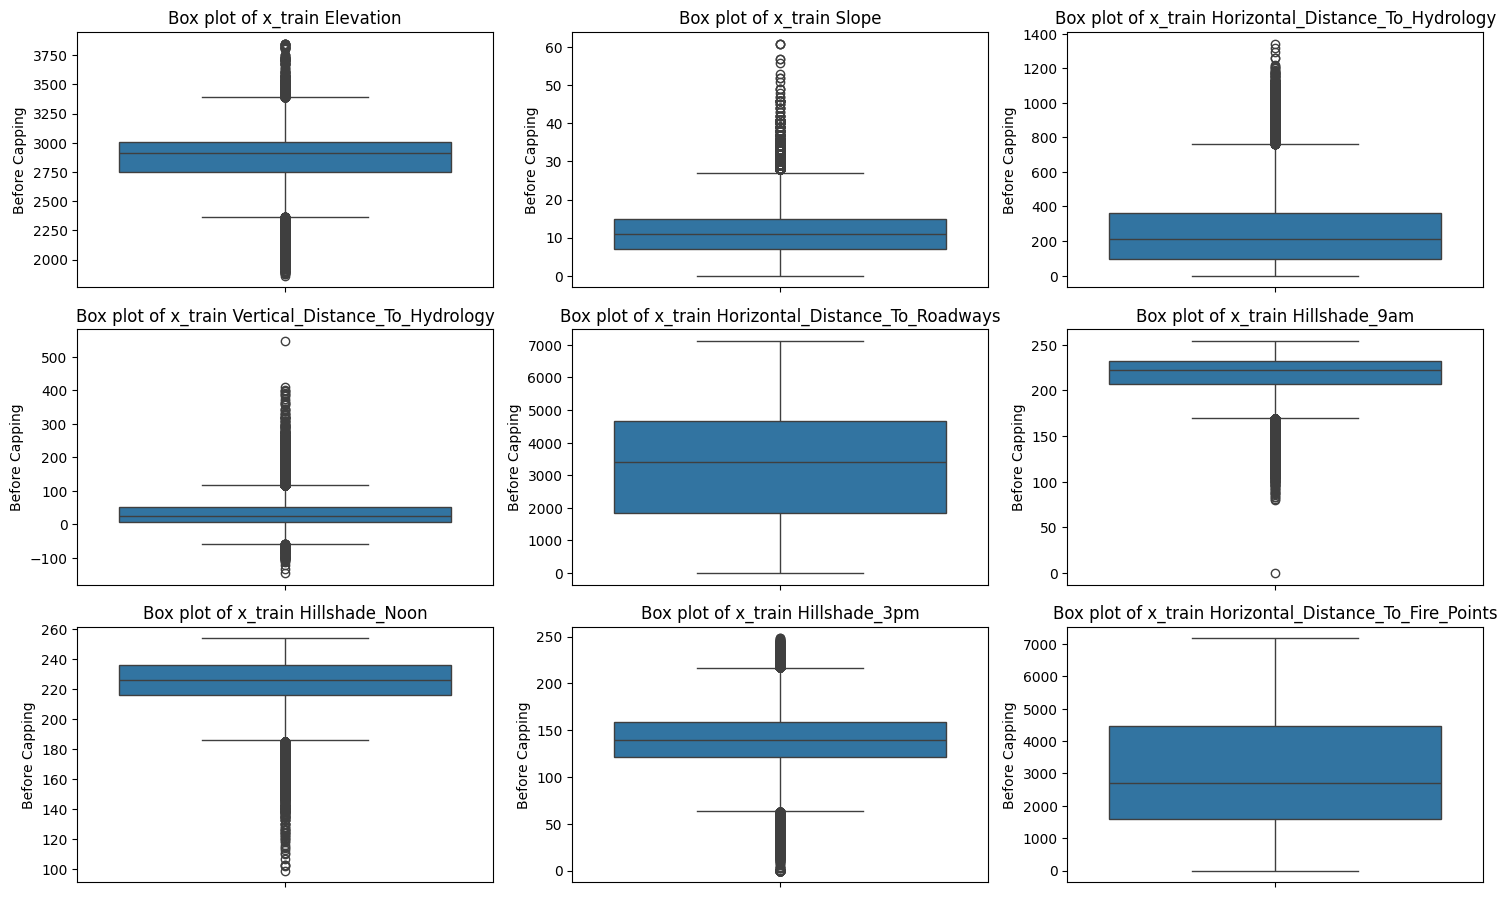

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize outliers in numerical features
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=train_features[col])
    plt.title(f'Box plot of x_train {col}')
    plt.ylabel('Before Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [16]:
# Calculate the number of outliers in the validation set
outlier_counts = count_outliers_iqr(valid_features, numerical_cols)

# Display the outlier count for each numerical feature
print("Outlier counts for each numerical feature:\n", outlier_counts)

Outlier counts for each numerical feature:
 {'Elevation': 643, 'Slope': 533, 'Horizontal_Distance_To_Hydrology': 317, 'Vertical_Distance_To_Hydrology': 1063, 'Horizontal_Distance_To_Roadways': 0, 'Hillshade_9am': 706, 'Hillshade_Noon': 506, 'Hillshade_3pm': 431, 'Horizontal_Distance_To_Fire_Points': 0}


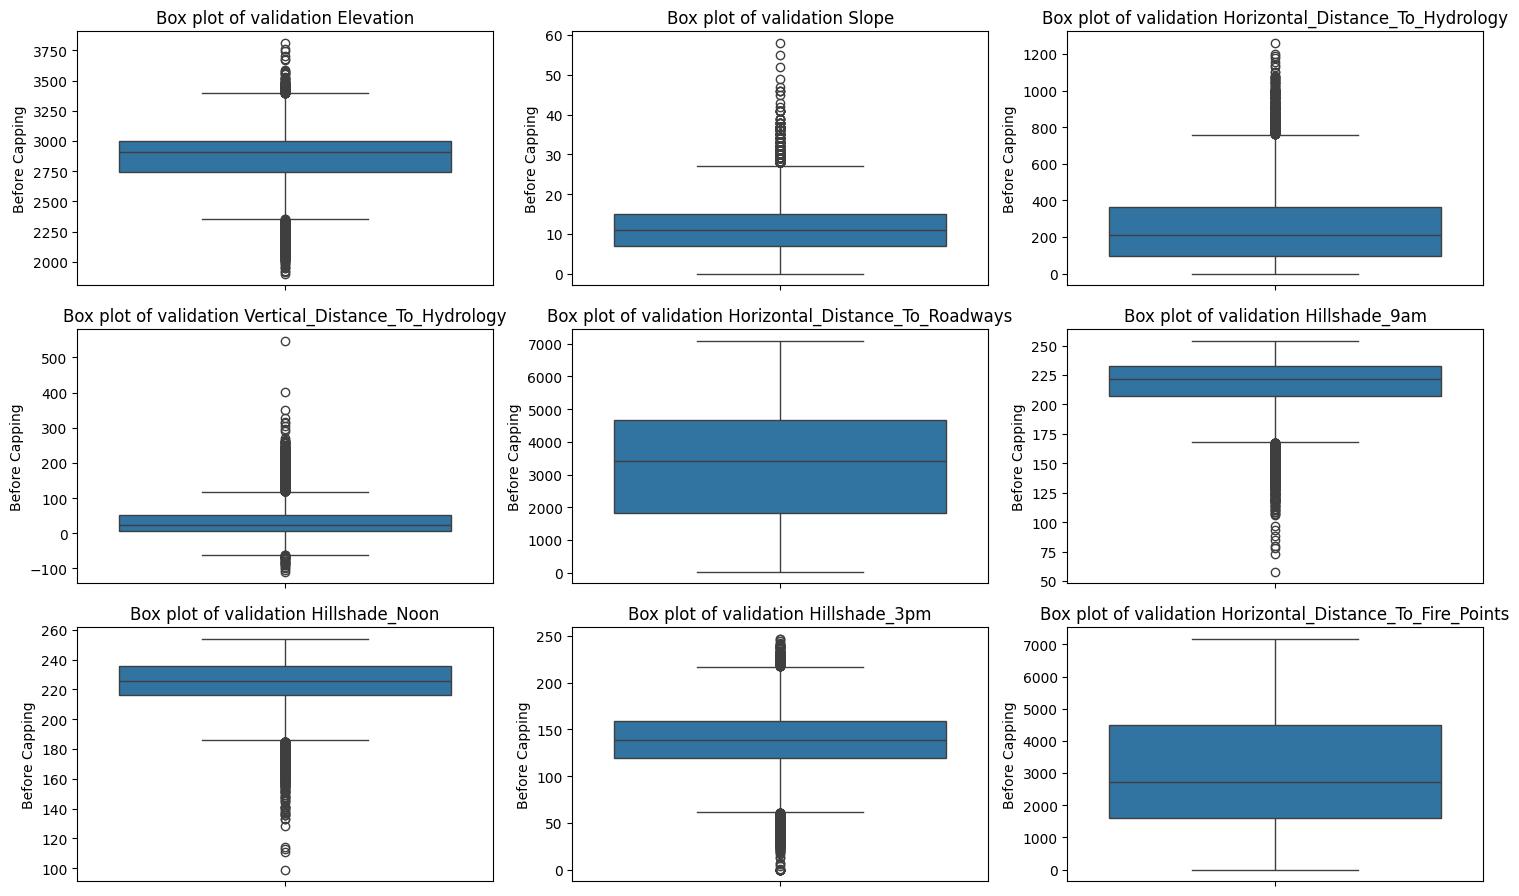

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize outliers in validation features
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=valid_features[col])
    plt.title(f'Box plot of validation {col}')
    plt.ylabel('Before Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [18]:
# Calculate the number of outliers in the test set
outlier_counts = count_outliers_iqr(test_features, numerical_cols)

# Display the outlier count for each numerical feature
print("Outlier counts for each numerical feature:\n", outlier_counts)

Outlier counts for each numerical feature:
 {'Elevation': 658, 'Slope': 475, 'Horizontal_Distance_To_Hydrology': 318, 'Vertical_Distance_To_Hydrology': 1058, 'Horizontal_Distance_To_Roadways': 0, 'Hillshade_9am': 803, 'Hillshade_Noon': 441, 'Hillshade_3pm': 457, 'Horizontal_Distance_To_Fire_Points': 0}


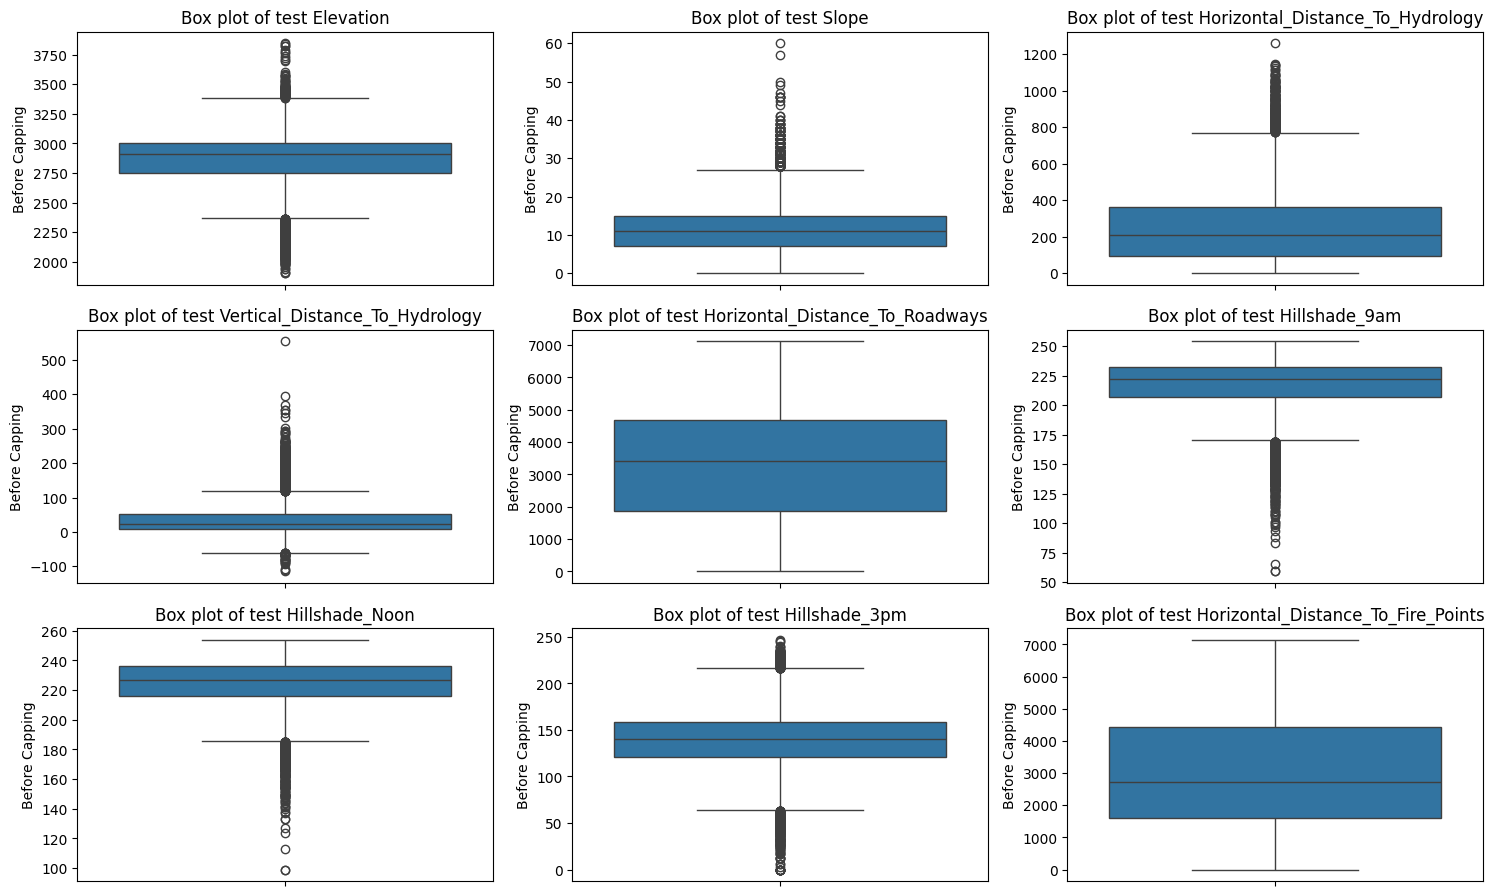

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize outliers in test features
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=test_features[col])
    plt.title(f'Box plot of test {col}')
    plt.ylabel('Before Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [20]:
# Define a function to fit IQR bounds and cap outliers in numerical features
def iqr_capping_fit_transform(df, cols):
    bounds = {}

    for col in cols:
        # Calculate Q1, Q3, and IQR for the column
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for capping
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Store the capping bounds for each feature
        bounds[col] = (lower, upper)

        # Cap values outside the IQR bounds
        df[col] = df[col].clip(lower=lower, upper=upper)

    return df, bounds

In [21]:
# Define a function to apply the fitted IQR bounds to new data
def iqr_capping_transform(df, cols, bounds):
    for col in cols:
        # Retrieve the lower and upper bounds for the feature
        lower, upper = bounds[col]

        # Cap values outside the fitted IQR bounds
        df[col] = df[col].clip(lower=lower, upper=upper)

    return df

In [22]:
# Fit the IQR capping bounds on the training data
X_train, bounds = iqr_capping_fit_transform(train_features, numerical_cols)

# Apply the training bounds to the validation data
X_valid = iqr_capping_transform(valid_features, numerical_cols, bounds)

# Apply the training bounds to the test data
X_test = iqr_capping_transform(test_features, numerical_cols, bounds)

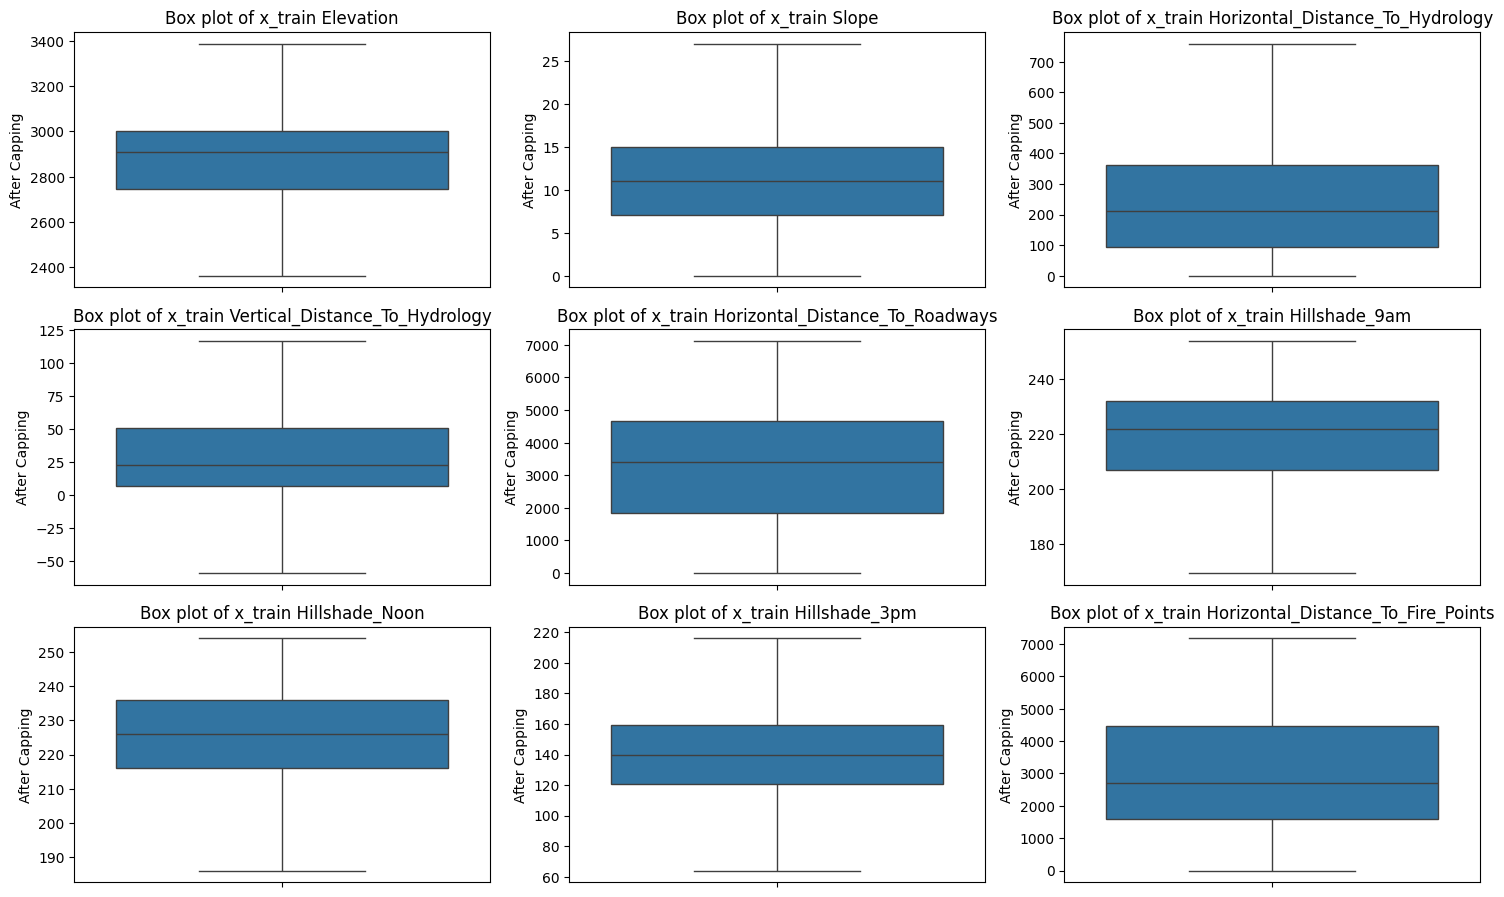

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize the capped numerical features
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=train_features[col])
    plt.title(f'Box plot of x_train {col}')
    plt.ylabel('After Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

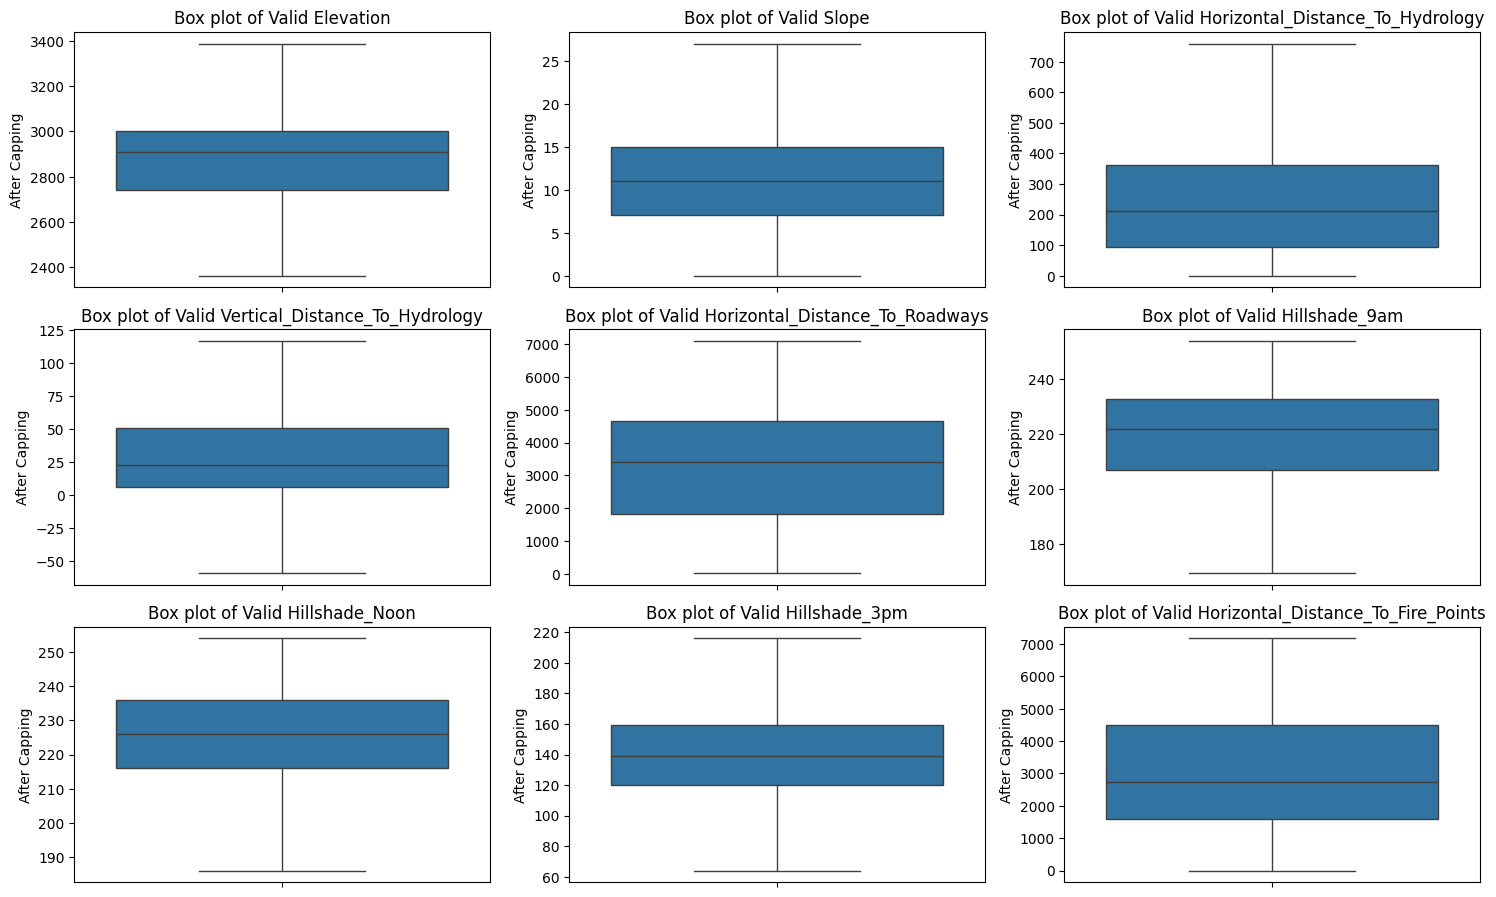

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize the capped numerical features in the validation set
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=valid_features[col])
    plt.title(f'Box plot of Valid {col}')
    plt.ylabel('After Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

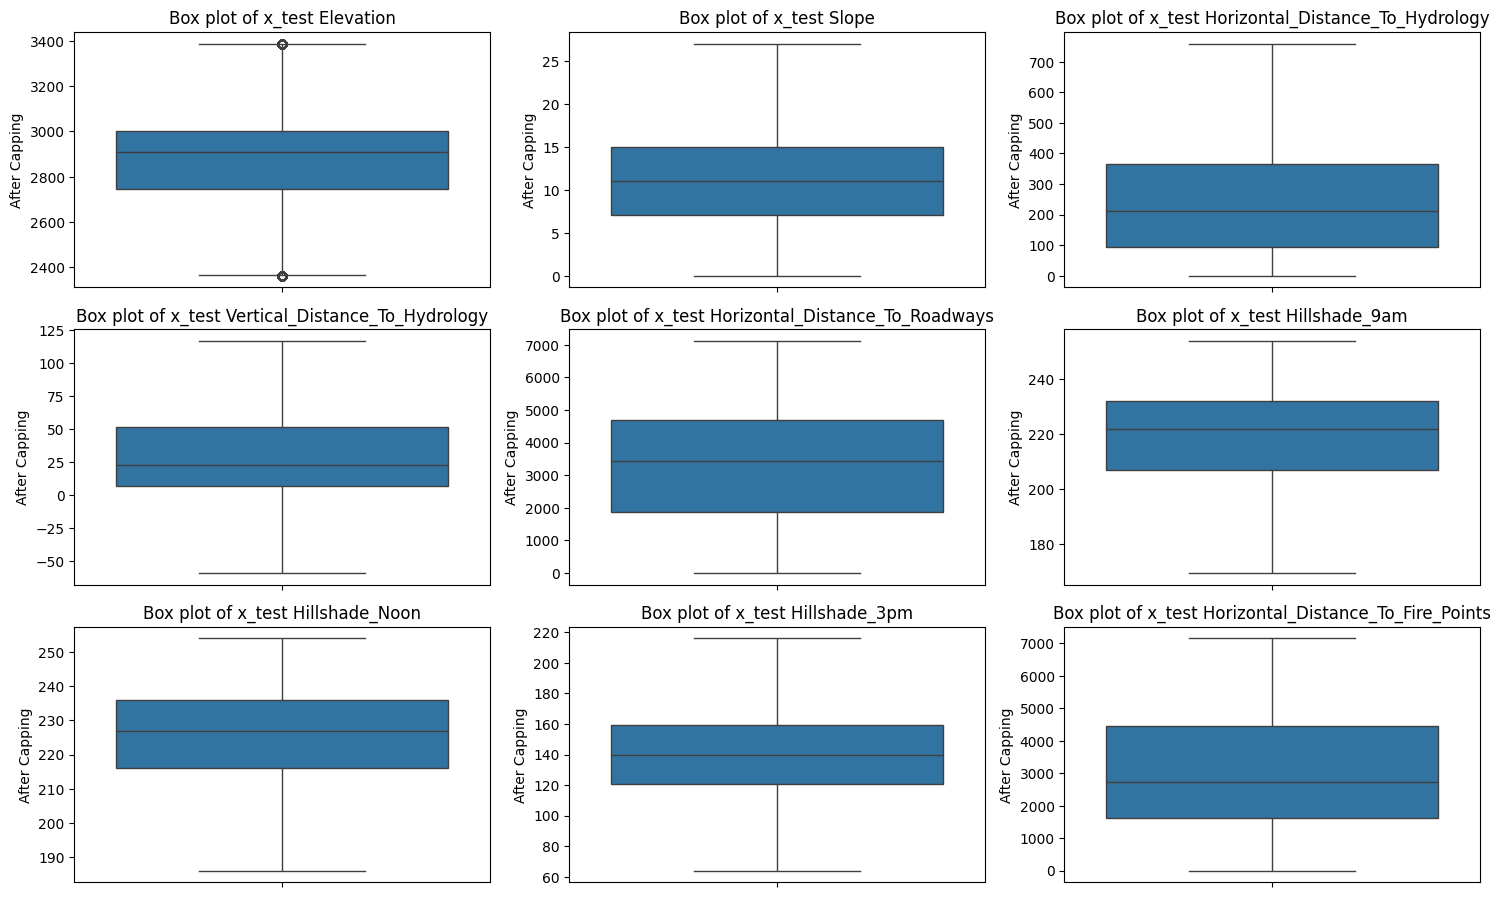

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots to visualize the capped numerical features in the test set
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=test_features[col])
    plt.title(f'Box plot of x_test {col}')
    plt.ylabel('After Capping')

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [26]:
# Calculate skewness for continuous numerical features
skewness = train_features[numerical_cols].skew()

# Display the skewness values for each continuous feature
print("Skewness for continuous features:\n", skewness)

Skewness for continuous features:
 Elevation                            -0.337638
Slope                                 0.621540
Horizontal_Distance_To_Hydrology      0.797475
Vertical_Distance_To_Hydrology        0.860820
Horizontal_Distance_To_Roadways      -0.060116
Hillshade_9am                        -0.734987
Hillshade_Noon                       -0.502442
Hillshade_3pm                        -0.001898
Horizontal_Distance_To_Fire_Points    0.367345
dtype: float64


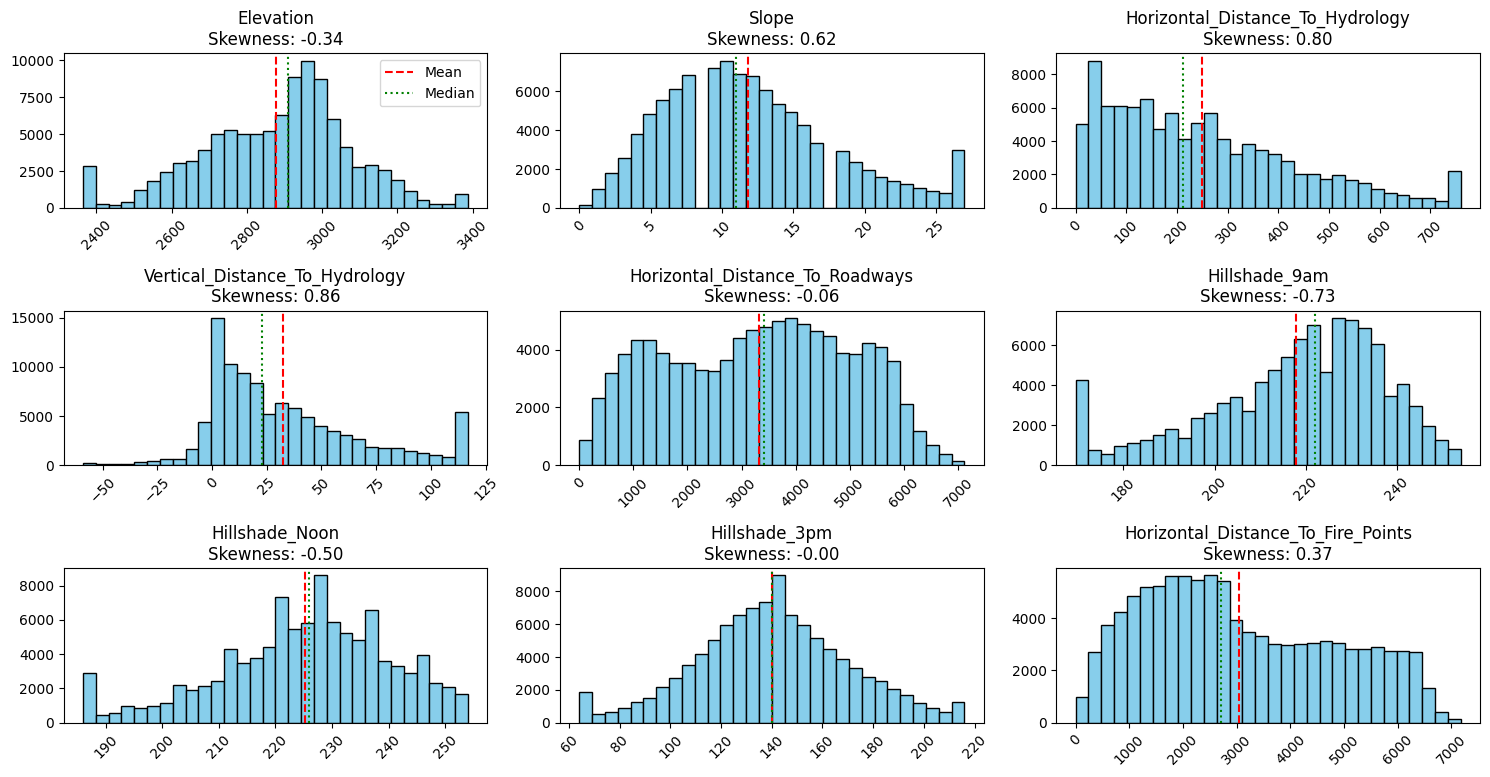

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Select all continuous features for histogram visualization
skewed_cols = skewness.index

plt.figure(figsize=(15, 10))

for i, col in enumerate(skewed_cols, 1):
    plt.subplot(4, 3, i)

    # Plot the feature distribution
    plt.hist(train_features[col], bins=30, color='skyblue', edgecolor='black')

    # Add mean and median reference lines
    plt.axvline(train_features[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
    plt.axvline(np.median(train_features[col]), color='green', linestyle='dotted', linewidth=1.5, label='Median')

    # Display the feature name and skewness value
    plt.title(f"{col}\nSkewness: {skewness[col]:.2f}")
    plt.xticks(rotation=45)

    # Display the legend only for the first subplot
    if i == 1:
        plt.legend()

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [28]:
# Calculate skewness for continuous numerical features in the validation set
skewness = valid_features[numerical_cols].skew()

# Display the skewness values for each continuous feature
print("Skewness for continuous features:\n", skewness)

Skewness for continuous features:
 Elevation                            -0.325135
Slope                                 0.629393
Horizontal_Distance_To_Hydrology      0.775734
Vertical_Distance_To_Hydrology        0.878453
Horizontal_Distance_To_Roadways      -0.043296
Hillshade_9am                        -0.753633
Hillshade_Noon                       -0.525851
Hillshade_3pm                        -0.007096
Horizontal_Distance_To_Fire_Points    0.352489
dtype: float64


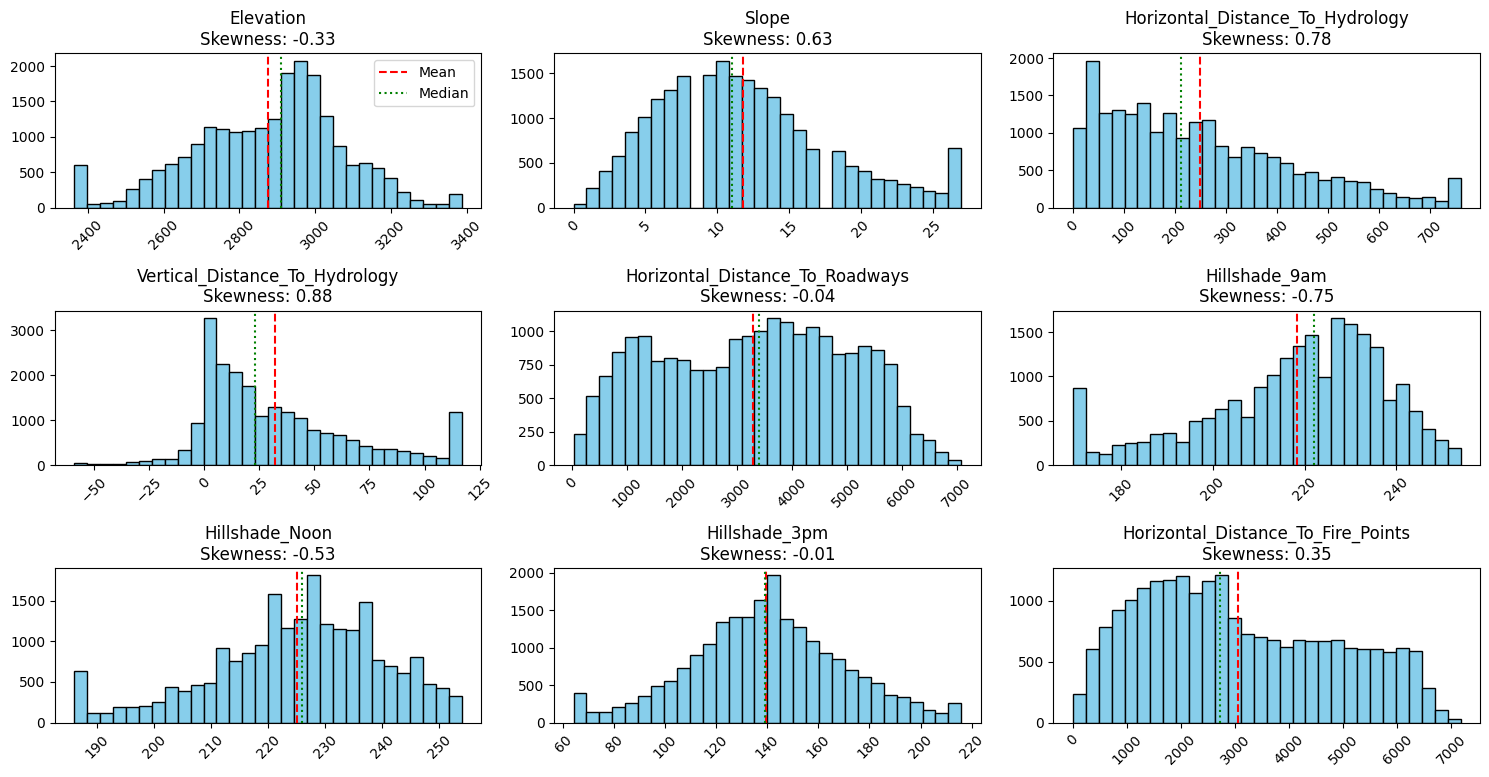

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Select all continuous features for histogram visualization
skewed_cols = skewness.index

plt.figure(figsize=(15, 10))

for i, col in enumerate(skewed_cols, 1):
    plt.subplot(4, 3, i)

    # Plot the feature distribution
    plt.hist(valid_features[col], bins=30, color='skyblue', edgecolor='black')

    # Add mean and median reference lines
    plt.axvline(valid_features[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
    plt.axvline(np.median(valid_features[col]), color='green', linestyle='dotted', linewidth=1.5, label='Median')

    # Display the feature name and skewness value
    plt.title(f"{col}\nSkewness: {skewness[col]:.2f}")
    plt.xticks(rotation=45)

    # Display the legend only for the first subplot
    if i == 1:
        plt.legend()

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [30]:
# Calculate skewness for continuous numerical features in the test set
skewness = test_features[numerical_cols].skew()

# Display the skewness values for each continuous feature
print("Skewness for continuous features:\n", skewness)

Skewness for continuous features:
 Elevation                            -0.343607
Slope                                 0.612621
Horizontal_Distance_To_Hydrology      0.764794
Vertical_Distance_To_Hydrology        0.846371
Horizontal_Distance_To_Roadways      -0.064453
Hillshade_9am                        -0.752598
Hillshade_Noon                       -0.498843
Hillshade_3pm                         0.007815
Horizontal_Distance_To_Fire_Points    0.368231
dtype: float64


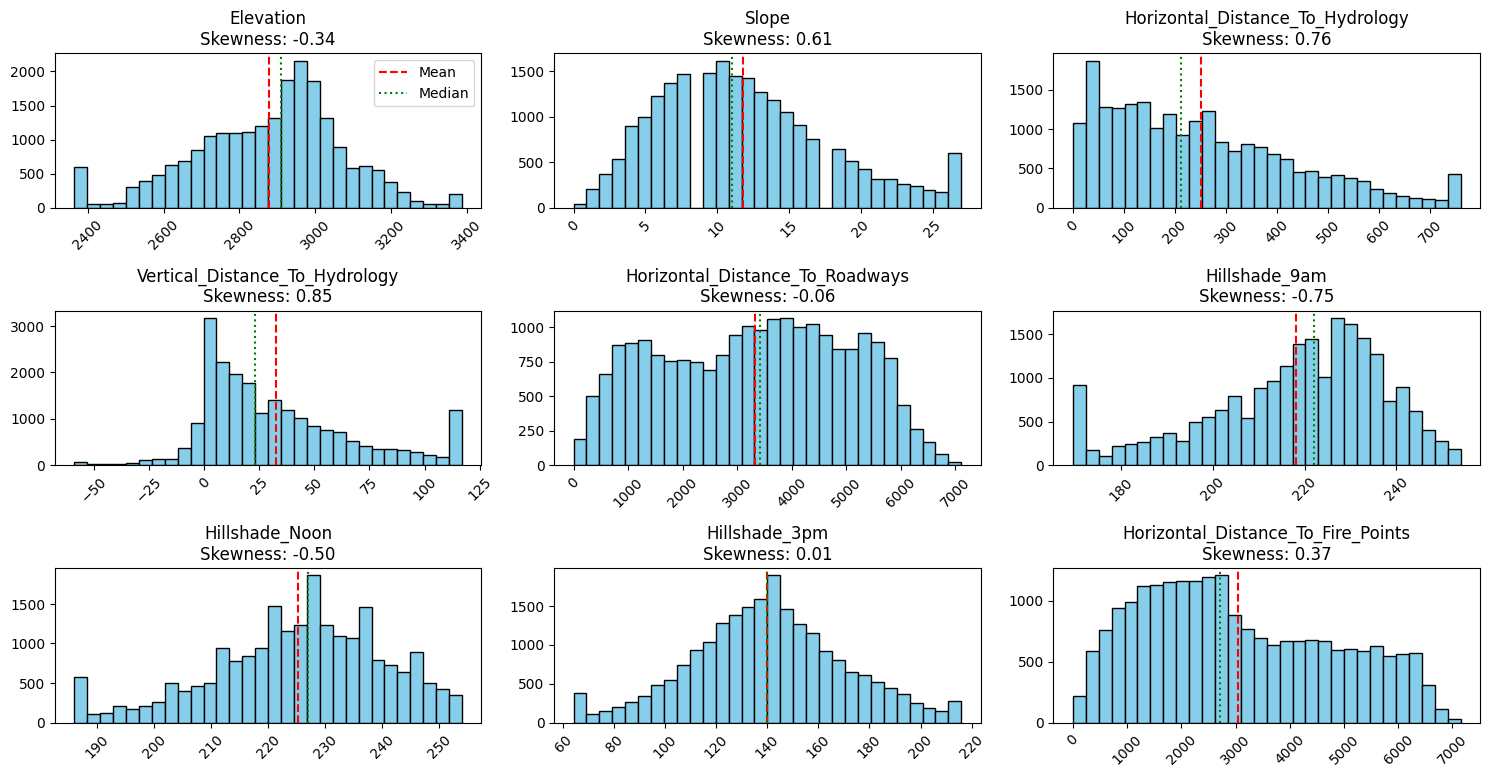

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Select all continuous features for histogram visualization
skewed_cols = skewness.index

plt.figure(figsize=(15, 10))

for i, col in enumerate(skewed_cols, 1):
    plt.subplot(4, 3, i)

    # Plot the feature distribution
    plt.hist(test_features[col], bins=30, color='skyblue', edgecolor='black')

    # Add mean and median reference lines
    plt.axvline(test_features[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
    plt.axvline(np.median(test_features[col]), color='green', linestyle='dotted', linewidth=1.5, label='Median')

    # Display the feature name and skewness value
    plt.title(f"{col}\nSkewness: {skewness[col]:.2f}")
    plt.xticks(rotation=45)

    # Display the legend only for the first subplot
    if i == 1:
        plt.legend()

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import PowerTransformer

# Initialize the Yeo-Johnson power transformer
power_transformer = PowerTransformer(method='yeo-johnson')

# Apply the transformation to training features
transformed_train_features = train_features.copy()

transformed_train_features[skewed_cols] = power_transformer.fit_transform(
    train_features[skewed_cols]
)

# Apply the fitted transformer to validation features
transformed_valid_features = valid_features.copy()

transformed_valid_features[skewed_cols] = power_transformer.transform(
    valid_features[skewed_cols]
)

# Apply the fitted transformer to test features
transformed_test_features = test_features.copy()

transformed_test_features[skewed_cols] = power_transformer.transform(
    test_features[skewed_cols]
)

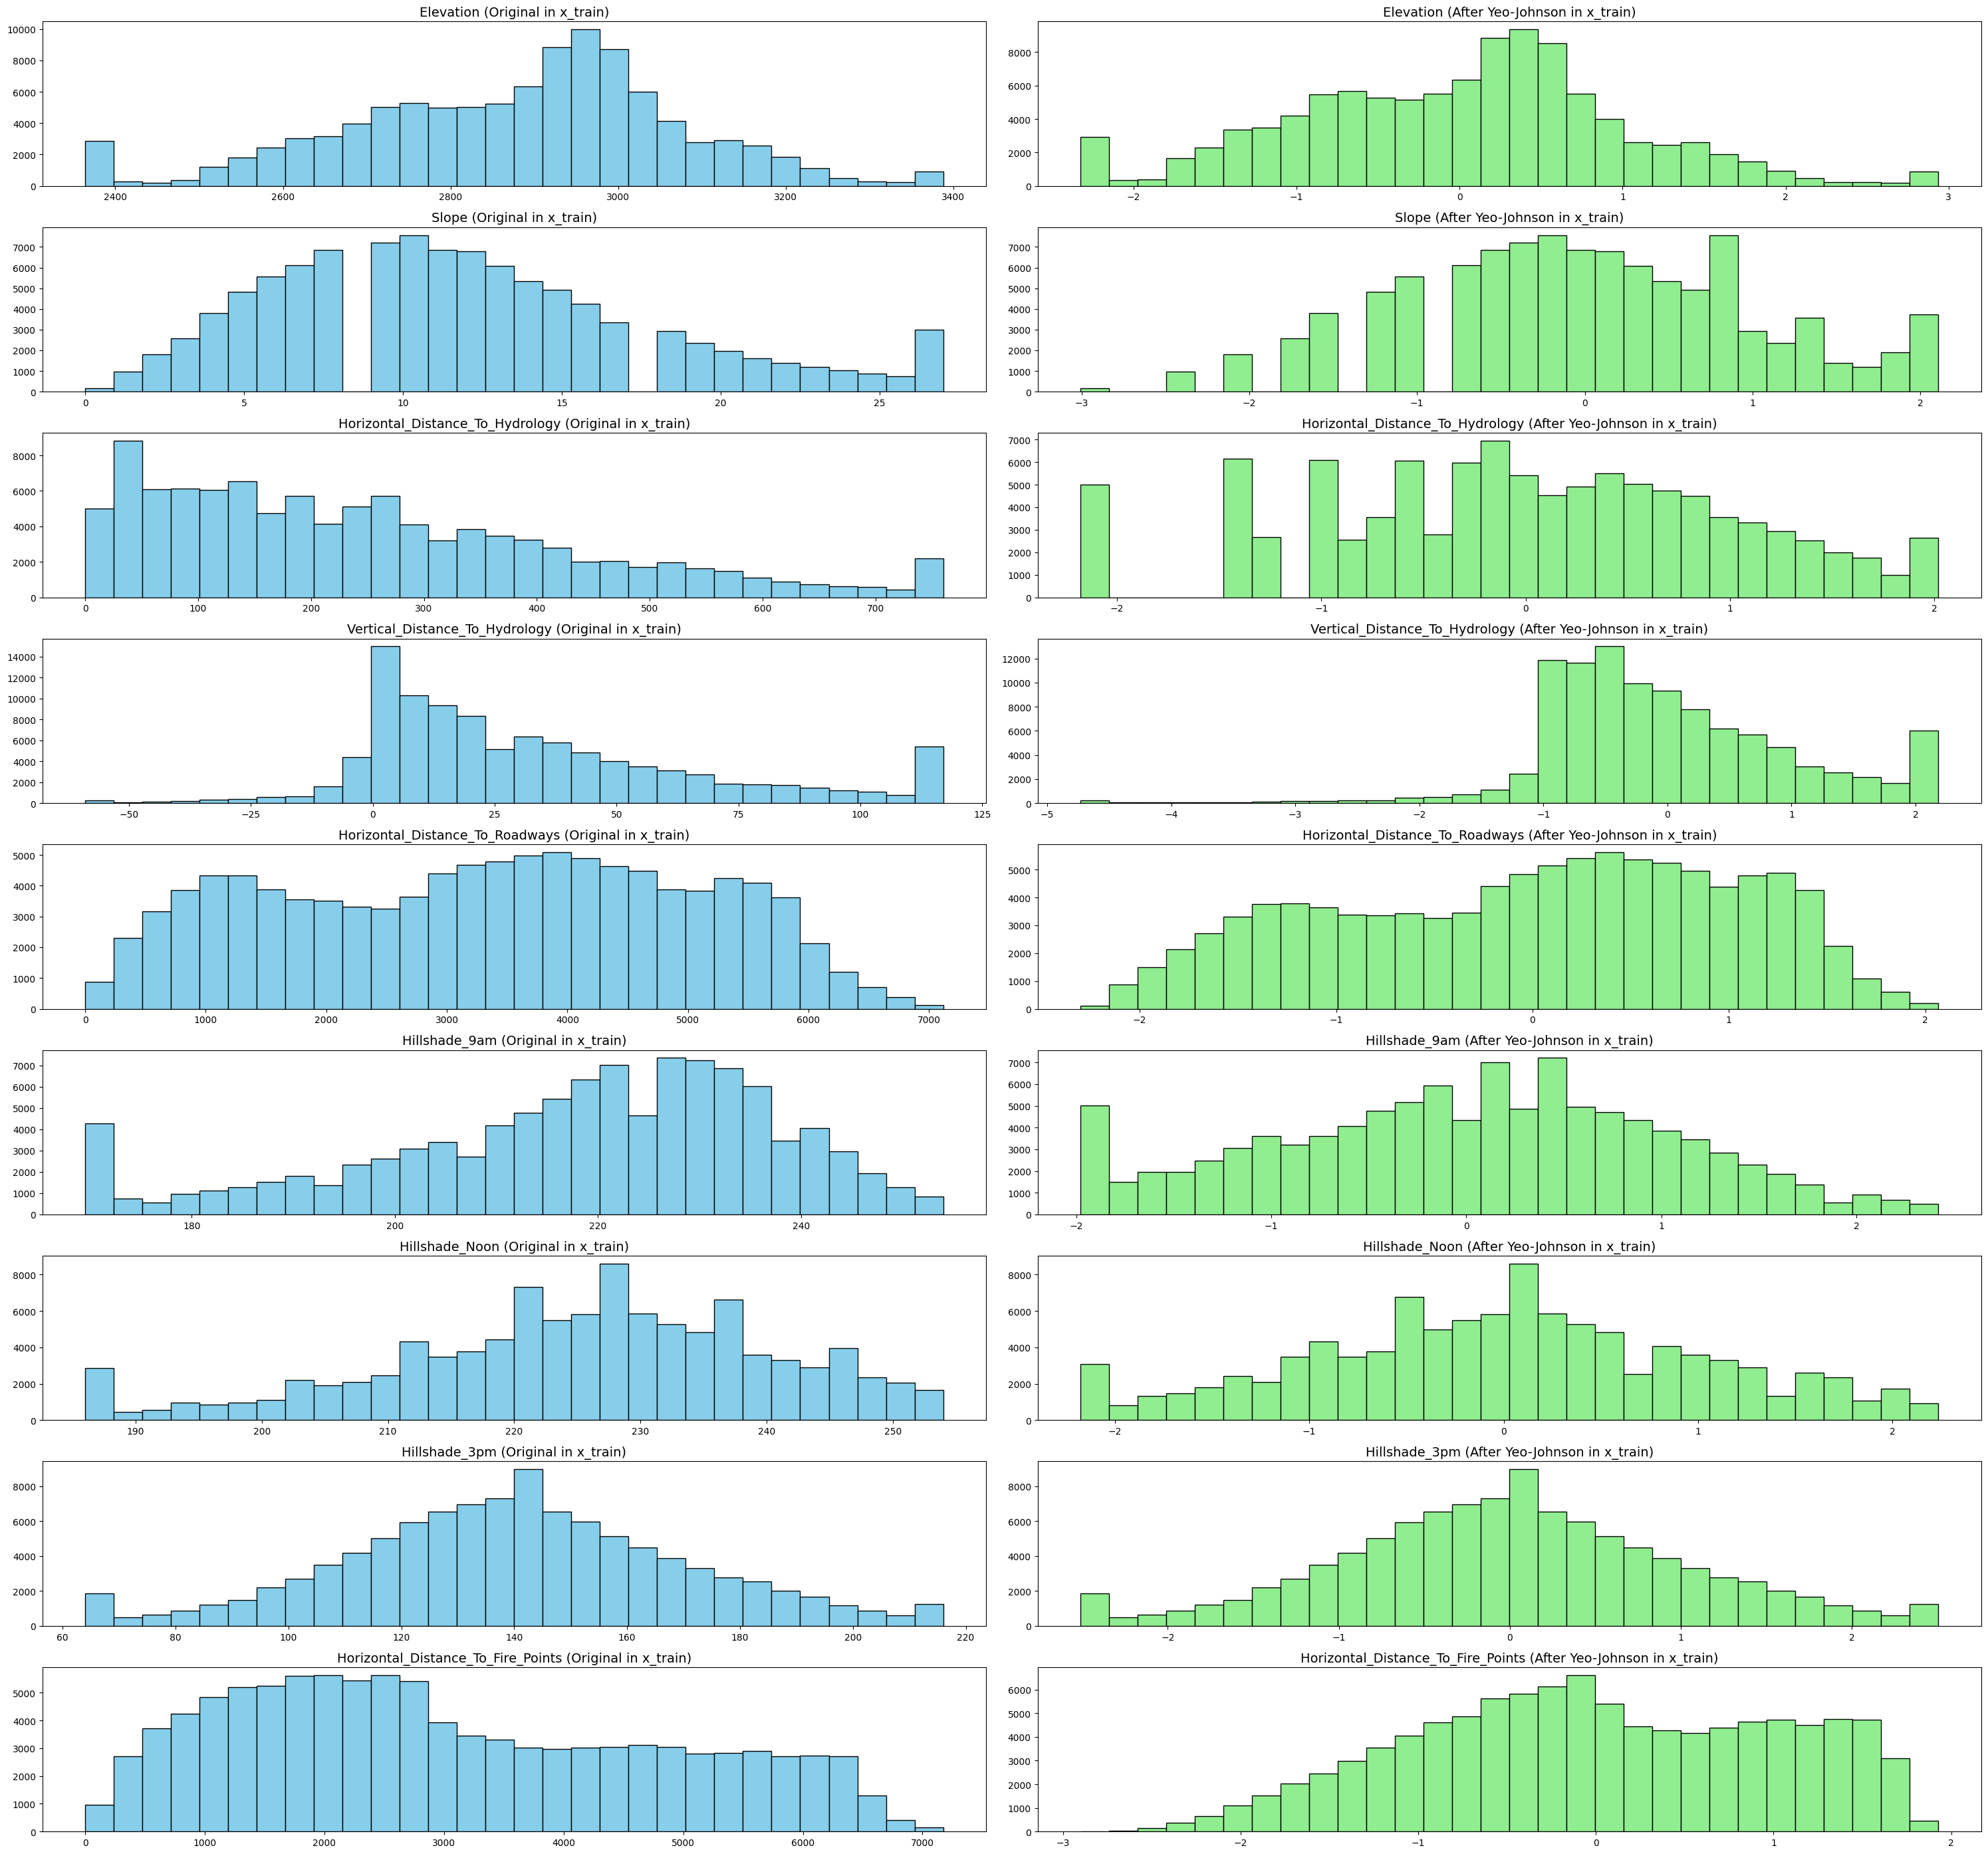

In [33]:
import matplotlib.pyplot as plt

# Compare feature distributions before and after Yeo-Johnson transformation
plt.figure(figsize=(30, 28))

for i, col in enumerate(skewed_cols, 1):
    # Plot the original feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i - 1)
    plt.hist(train_features[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (Original in x_train)", fontsize=14)

    # Plot the transformed feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i)
    plt.hist(transformed_train_features[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f"{col} (After Yeo-Johnson in x_train)", fontsize=14)

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

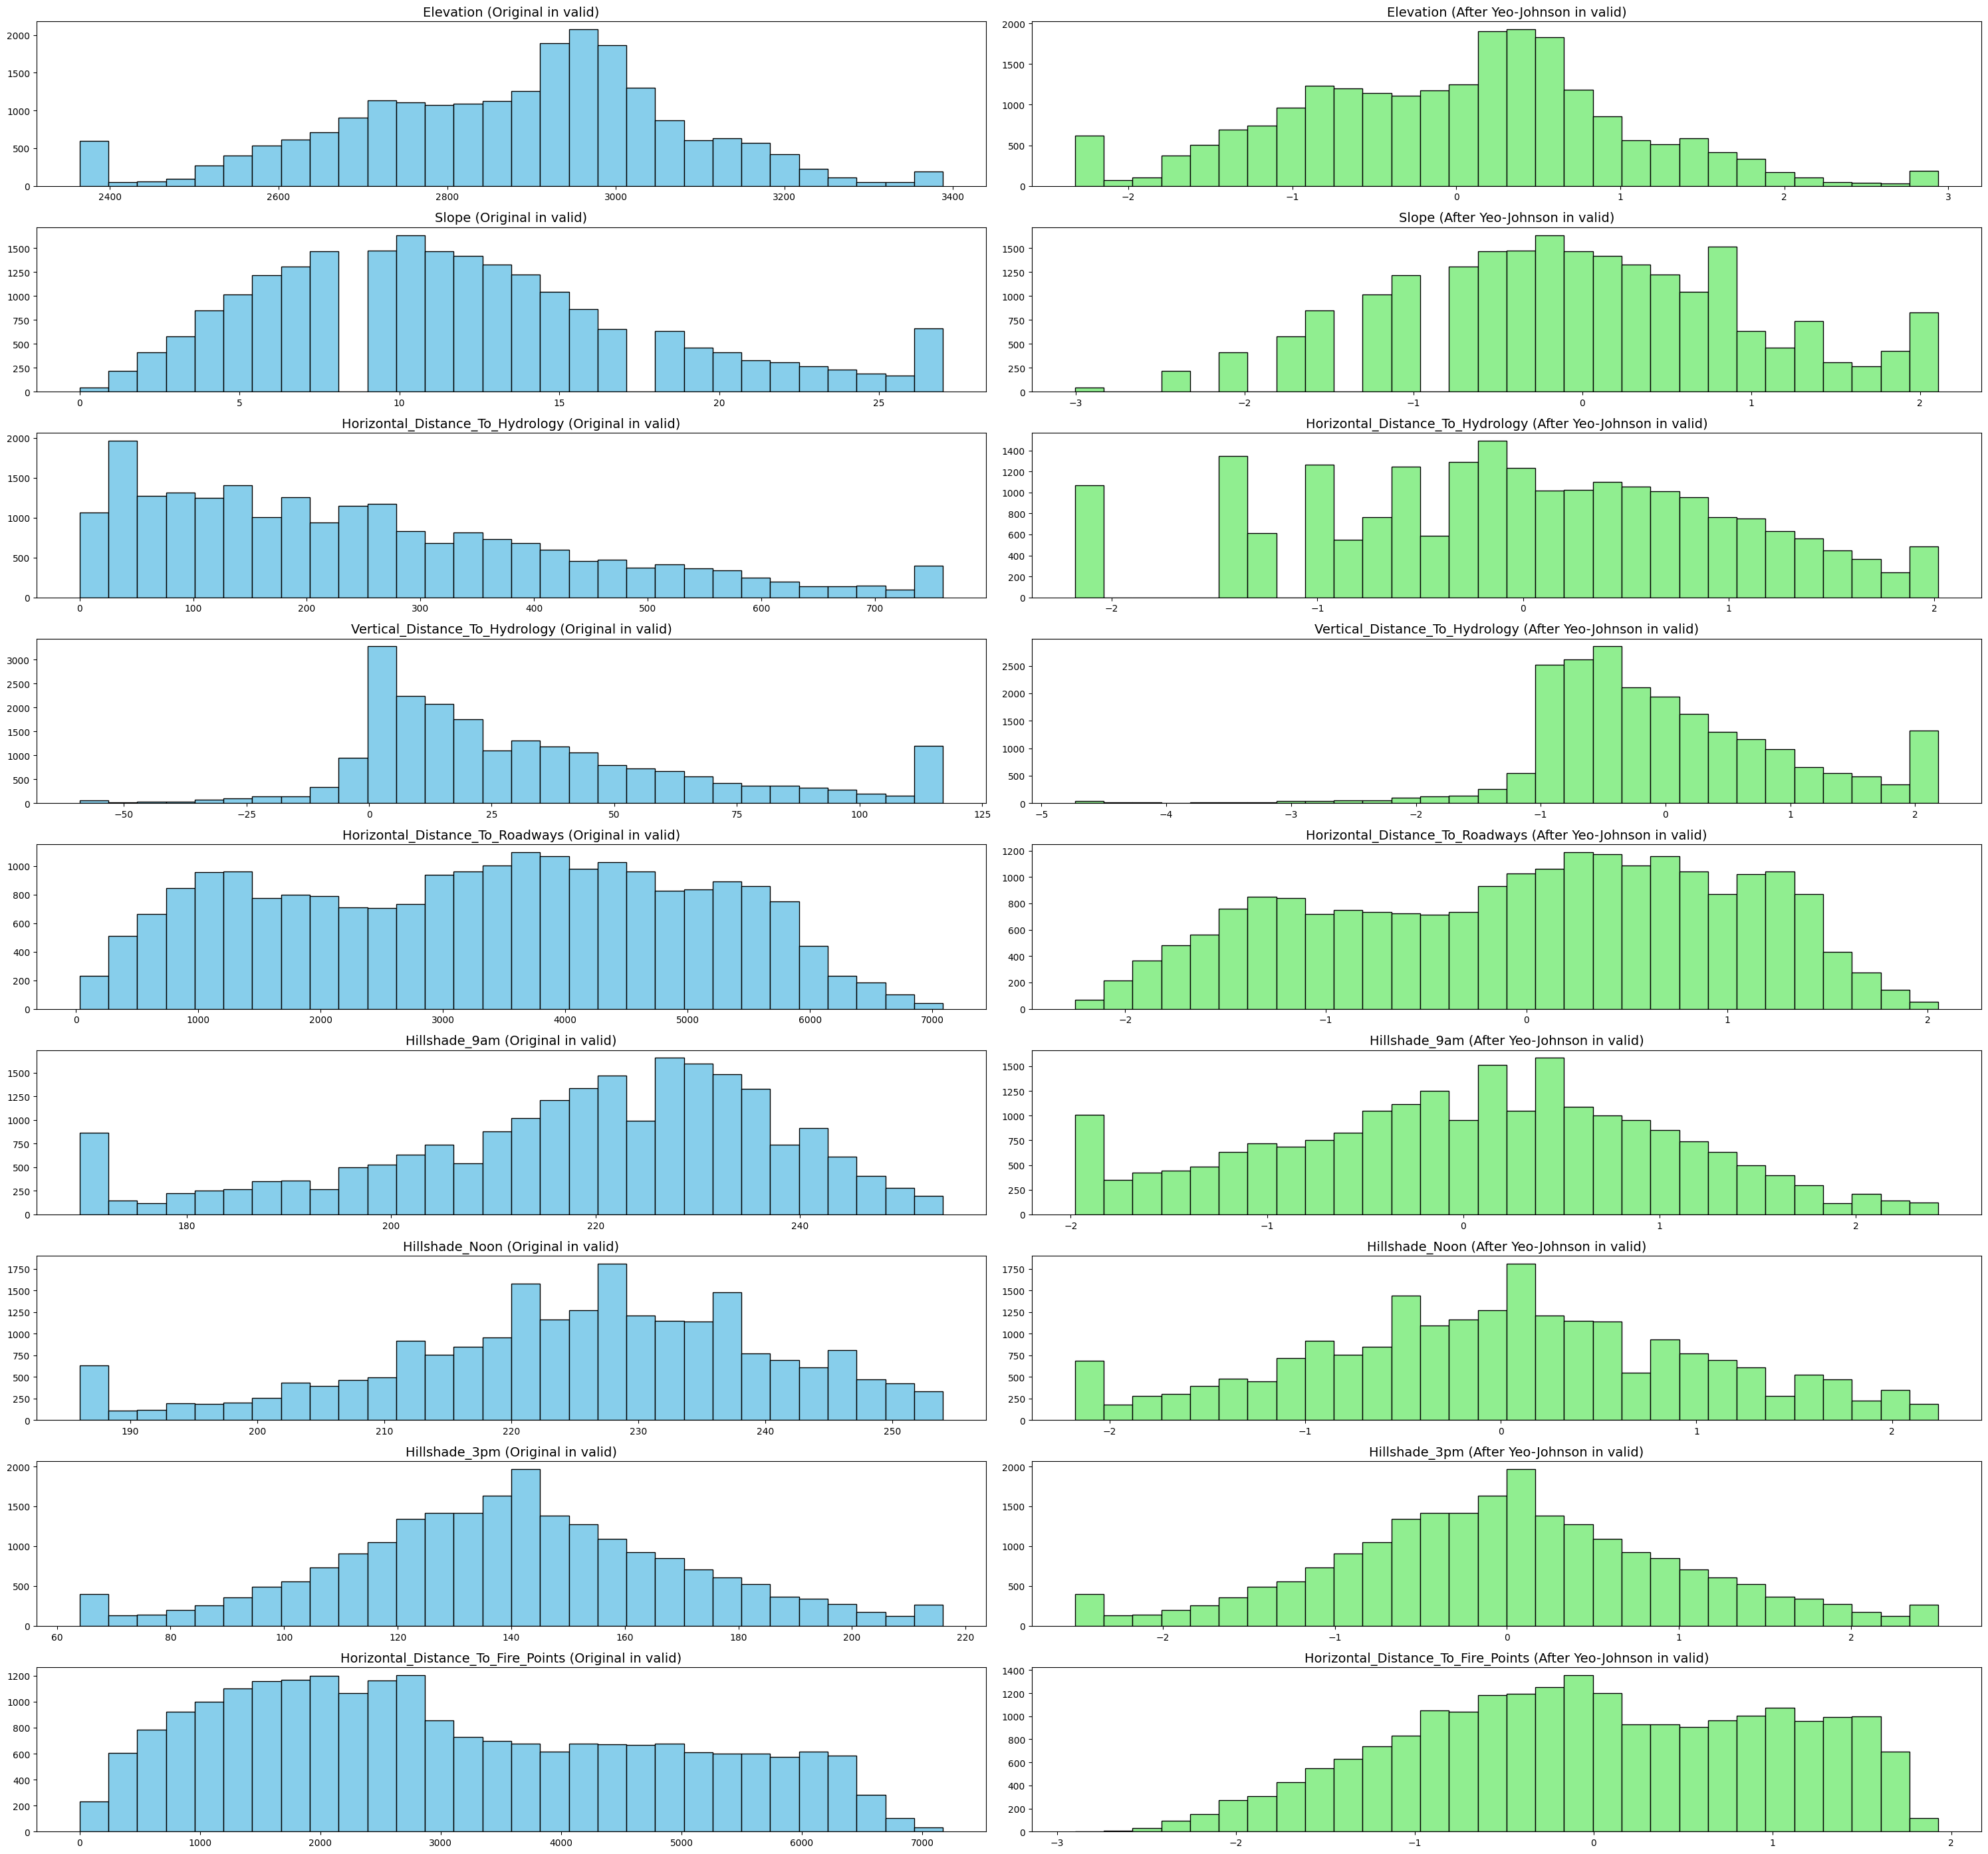

In [34]:
import matplotlib.pyplot as plt

# Compare validation feature distributions before and after Yeo-Johnson transformation
plt.figure(figsize=(30, 28))

for i, col in enumerate(skewed_cols, 1):
    # Plot the original feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i - 1)
    plt.hist(valid_features[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (Original in valid)", fontsize=14)

    # Plot the transformed feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i)
    plt.hist(transformed_valid_features[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f"{col} (After Yeo-Johnson in valid)", fontsize=14)

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

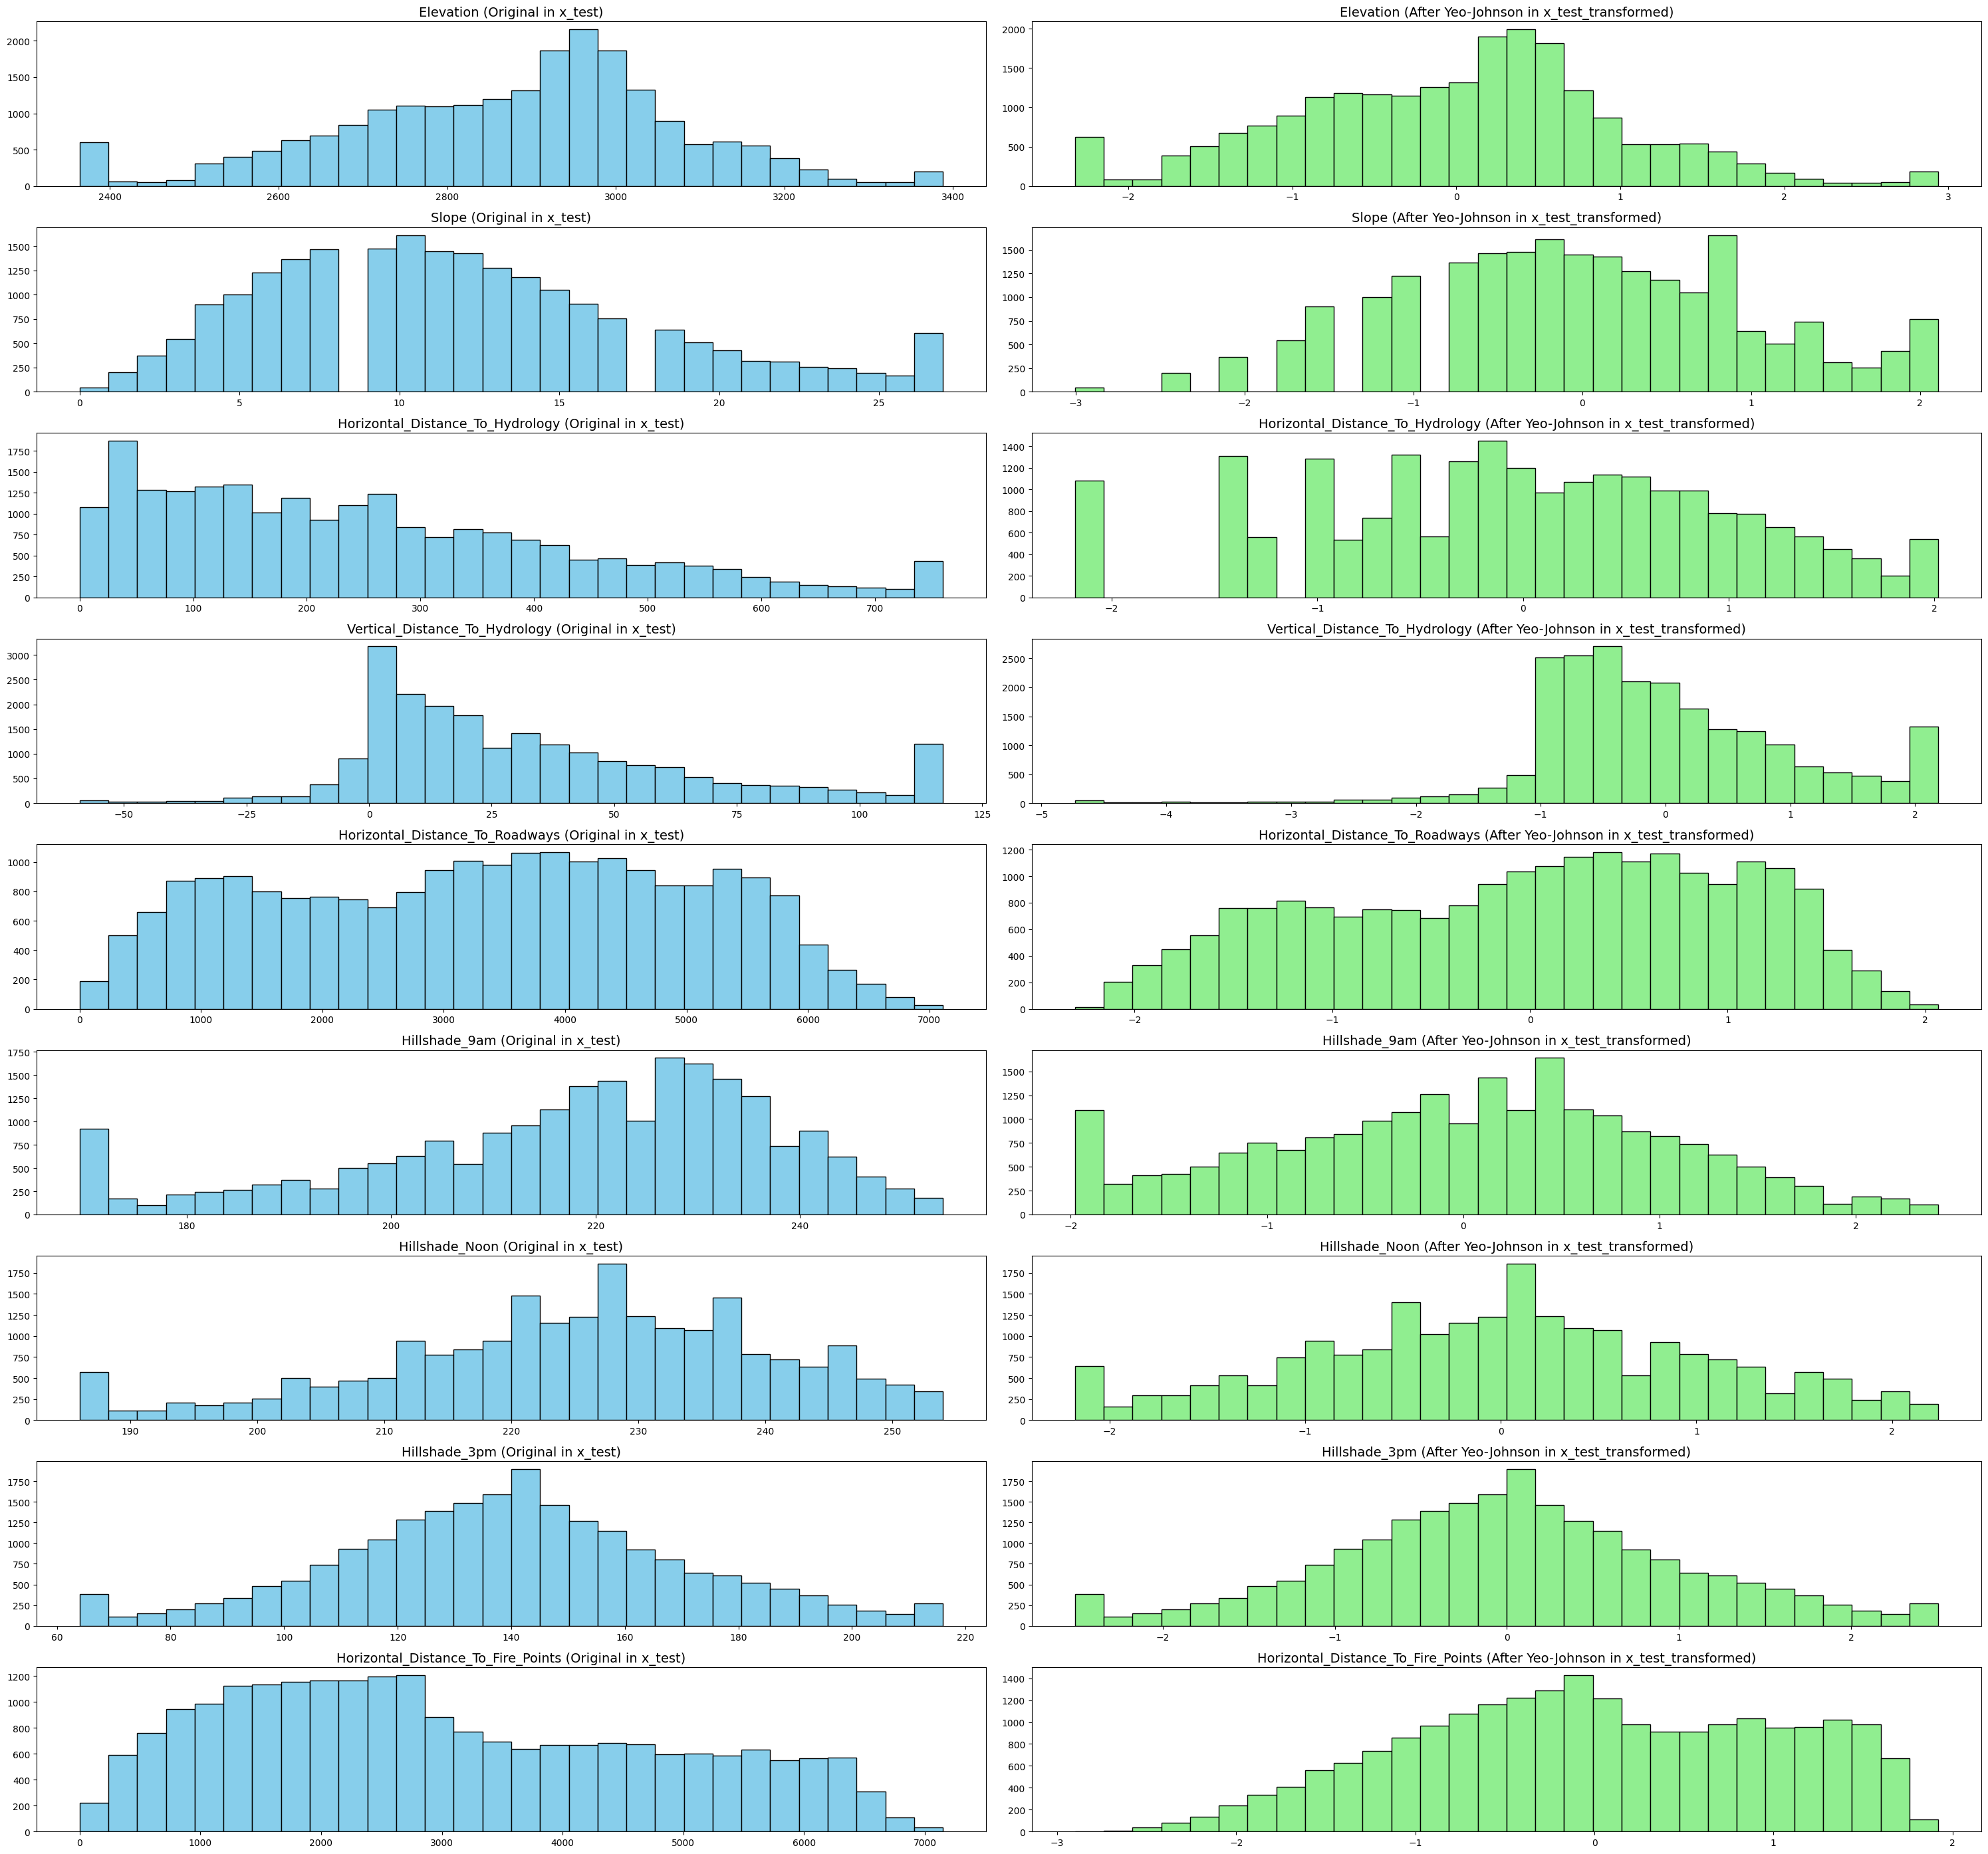

In [35]:
import matplotlib.pyplot as plt

# Compare test feature distributions before and after Yeo-Johnson transformation
plt.figure(figsize=(30, 28))

for i, col in enumerate(skewed_cols, 1):
    # Plot the original feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i - 1)
    plt.hist(test_features[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (Original in x_test)", fontsize=14)

    # Plot the transformed feature distribution
    plt.subplot(len(skewed_cols), 2, 2*i)
    plt.hist(transformed_test_features[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f"{col} (After Yeo-Johnson in x_test_transformed)", fontsize=14)

# Adjust the layout and display the plots
plt.tight_layout()
plt.show()

In [36]:
# Store the transformed feature sets and target variables for later use
%store transformed_train_features
%store transformed_test_features
%store transformed_valid_features
%store train_labels
%store test_labels
%store valid_labels

Stored 'transformed_train_features' (DataFrame)
Stored 'transformed_test_features' (DataFrame)
Stored 'transformed_valid_features' (DataFrame)
Stored 'train_labels' (Series)
Stored 'test_labels' (Series)
Stored 'valid_labels' (Series)
